This notebook is a data-cleaned version of solo_analysis.ipynb

Currently only data skewed by the time lock-in constant has been cleaned

In [2]:
# Import necessary librarys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import medfilt


**Import single .txt file**

In [3]:
# Import .txt file

# Available samples: (PB2, SN, IN, SNPB, PTFE, IN2BI, IN4BI, CU, PB0, PB1)
# Replace blank in "meissner/__/sc_data/__.__.txt" with sample name and temp
df_unclean = pd.read_csv("meissner/IN2BI/sc_data/IN2BI_1.5.txt", sep=r"\s+")

**Clean data for time graphs**

In [7]:
# Separate and Clean Data


# Time lock-in Filtering

# Time data
time_unclean = df_unclean["Time(s)"]

# Time lock-in constant
tau = 0.3

# Cut-off time (~0.7% error remains)
cutoff = 5 * tau

# Trim start of data
mask = time_unclean > cutoff

df = df_unclean[mask]

# Pull time cleaned data
time = df["Time(s)"]
kGauss_time_cleaned = df["Channel_1(V)"].abs() # Our field sweep is negative, but we only care about the amplitude, so we take the absolute value to make it more readible visually
voltage_time_cleaned = df["Channel_2(V)"].abs()
# angle_cleaned = df_cleaned["Channel_3(V)"] -- Unused, here for clarity


# Median Filter 

# Elimantes noise spikes from touching cables, etc

voltage = medfilt(voltage_time_cleaned, kernel_size=13)  # kernel_size must be odd; 13 seems to be best fit
kGauss = kGauss_time_cleaned # Doesn't change

**Plot time graphs**

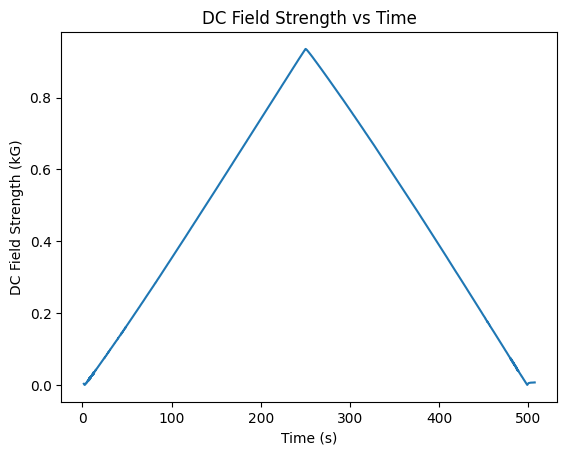

In [5]:
# Plot kGauss vs Time Graph

plt.figure()  # Could replace this with plt.subplot(), depending on vibes
plt.plot(time, kGauss)
plt.xlabel("Time (s)")
plt.ylabel("DC Field Strength (kG)")
plt.title("DC Field Strength vs Time")

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

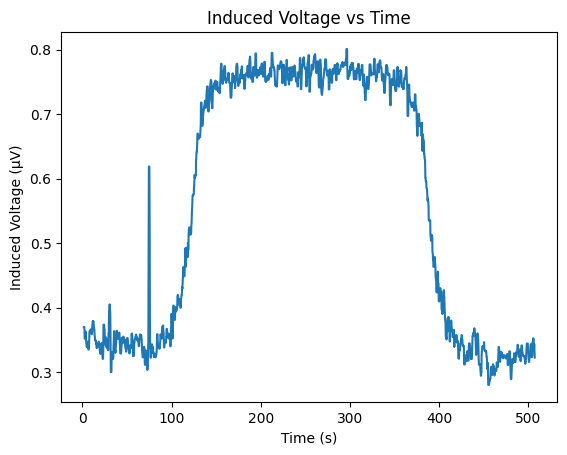

In [8]:
# Plot Induced Voltage vs Time Graph

plt.figure() # Could replace this with plt.subplot(), depending on vibes
plt.plot(time, voltage)
plt.xlabel("Time (s)")
plt.ylabel("Induced Voltage (\u03bcV)")
plt.title("Induced Voltage vs Time")

plt.show

**Clean data for voltage vs field graphs**

We will split our data into the upward sweep and the downward sweep when graphing and analyzing our induced voltage as a function of DC magentic field

This is done to account for hysteresis in the measuring instruments and produce a more accurate critical field

In [9]:
# Index where the field amplitude begins decreasing
max_field_idx = kGauss.idxmax() 


# Split data into increasing and decreasing part of sweeps
up_sweep = df.iloc[:max_field_idx + 1] # .iloc keeps the rows in our .txt file from the 0 index to the max_field_idx index
down_sweep = df.iloc[max_field_idx:]# .iloc keeps the rows in our .txt file from the max_field_idx index to our last index

# These both contain the row at the max_field_idx for an overlap of 1

# Separate kGauss data for our upward sweep and our downward sweep 
kGauss_up = up_sweep["Channel_1(V)"].abs()
kGauss_down = down_sweep["Channel_1(V)"].abs()

# Separate voltage data for our upward sweep and our downward sweep
voltage_up = medfilt(up_sweep["Channel_2(V)"], kernel_size=13)
voltage_down = medfilt(down_sweep["Channel_2(V)"], kernel_size=13)

# Separate kGauss data for our upward sweep and our downward sweep 
t_up = up_sweep["Time(s)"]
t_down = down_sweep["Time(s)"]


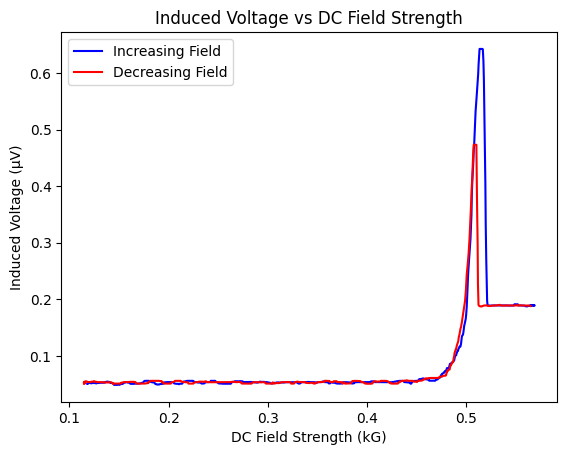

In [14]:
# Graph Induced Voltage vs kGauss


plt.figure  # Could replace this with plt.subplot(), depending on vibes
plt.plot(kGauss_up, voltage_up, label='Increasing Field', color='blue',) # Upward sweep is blue
plt.plot(kGauss_down, voltage_down, label='Decreasing Field', color='red') # Downward sweep is red
plt.xlabel("DC Field Strength (kG)")
plt.ylabel("Induced Voltage (\u03bcV)")
plt.title("Induced Voltage vs DC Field Strength")

plt.legend()
plt.show()

The following code is intended to find the first critical field for superconductor

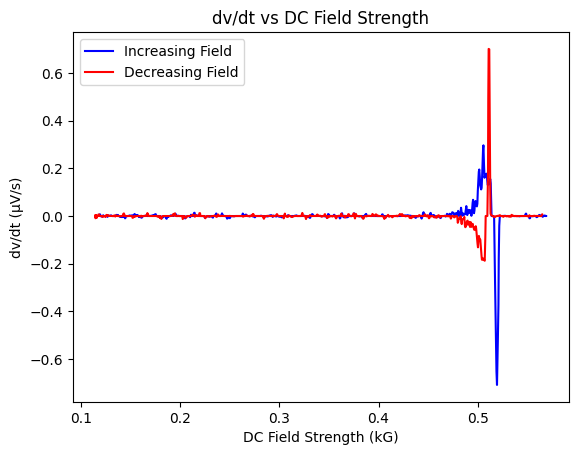

In [15]:
# Calculate dv/dt

d1v_up = np.gradient(voltage_up, t_up)
d1v_down = np.gradient(voltage_down, t_down)

# Plot dv/dkG

plt.figure  # Could replace this with plt.subplot(), depending on vibes
plt.plot(kGauss_up, d1v_up, label='Increasing Field', color='blue',) # Upward sweep is blue
plt.plot(kGauss_down, d1v_down, label='Decreasing Field', color='red') # Downward sweep is red
plt.xlabel("DC Field Strength (kG)")
plt.ylabel("dv/dt (\u03bcV/s)")
plt.title("dv/dt vs DC Field Strength")

plt.legend()
plt.show()

Find the critical field

In [217]:
# Critical field up
max_field_up_idx = np.argmax(d1v_up)
crit_up = kGauss_up.iloc[max_field_up_idx]

# Critical field down
max_field_down_idx = np.argmin(d1v_down)
crit_down = kGauss_down.iloc[max_field_down_idx]

# Critical field
critical_field = (crit_up + crit_down) / 2
print(critical_field)

0.5064554048764546
